In [19]:
import pandas as pd
import numpy as np
import gc
from google.colab import drive
drive.mount('/content/drive')

use_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
            'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
            'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME',
            'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']

# Load only 100,000 rows — fast and memory efficient
flights = pd.read_csv('/content/drive/MyDrive/flights.csv',
                      usecols=use_cols,
                      nrows=100000,
                      low_memory=False)

# Clean
flights.dropna(subset=['ARRIVAL_DELAY'], inplace=True)

# Create binary target
flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype(int)
flights.drop(columns=['ARRIVAL_DELAY'], inplace=True)

gc.collect()
print("Shape:", flights.shape)
print("Delay rate:", flights['DELAYED'].mean().round(3))
flights.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (97387, 11)
Delay rate: 0.345


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DELAYED
0,1,1,4,AS,ANC,SEA,5,205,1448,430,0
1,1,1,4,AA,LAX,PBI,10,280,2330,750,0
2,1,1,4,US,SFO,CLT,20,286,2296,806,0
3,1,1,4,AA,LAX,MIA,20,285,2342,805,0
4,1,1,4,AS,SEA,ANC,25,235,1448,320,0


In [17]:
pip install pycaret


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
categorical_cols = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    flights[col] = le.fit_transform(flights[col].astype(str))
    encoders[col] = le

# Features and target
X = flights.drop(columns=['DELAYED'])
y = flights['DELAYED']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (68170, 10)
Testing shape: (29217, 10)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "AUC": round(auc, 4)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="AUC", ascending=False)


Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...


,Model,Accuracy,AUC
3,XGBoost,0.7454,0.7832
1,Random Forest,0.7300,0.7622
2,Gradient Boosting,0.7159,0.7418
0,Logistic Regression,0.6776,0.6613


In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


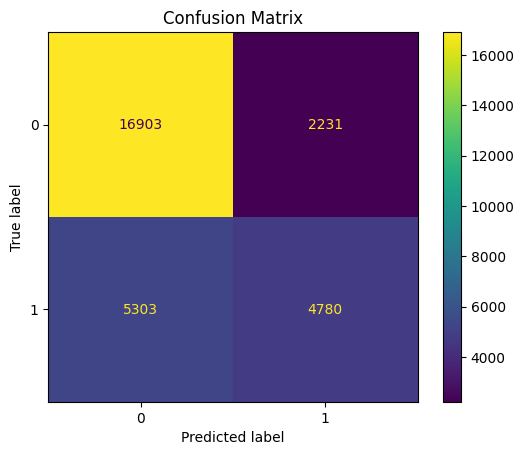

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

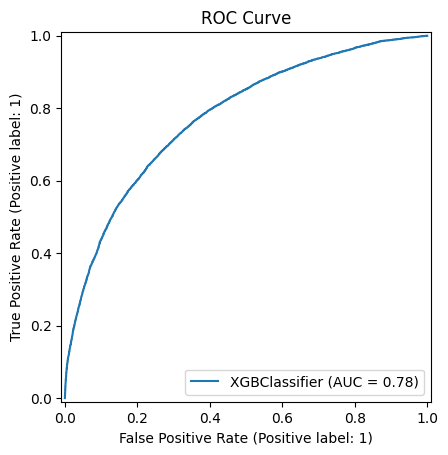

In [24]:

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()


In [ ]:
plot_model(xgb_model, plot='feature')

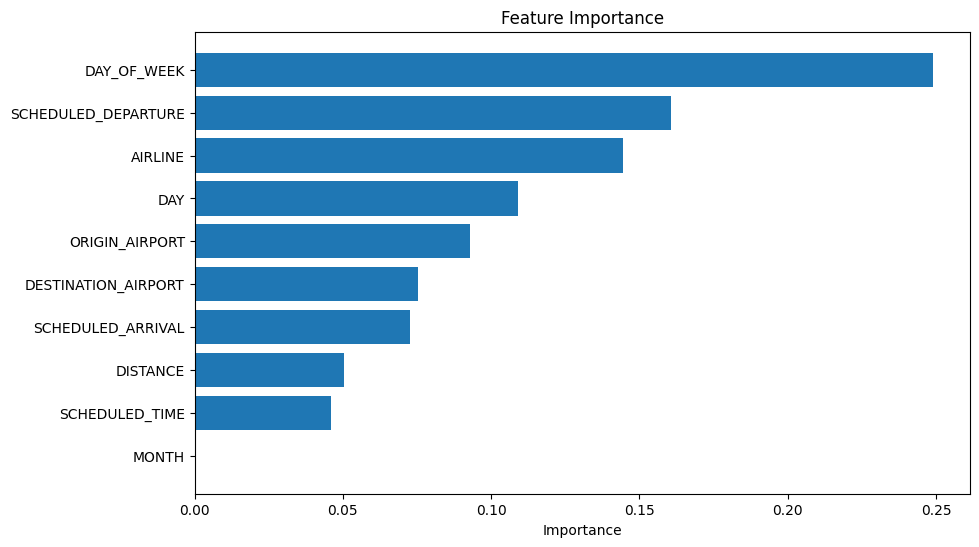

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

In [26]:
new_data = flights.iloc[:10].drop(columns=['DELAYED'])

# Predict class
pred_labels = xgb_model.predict(new_data)

# Predict probability
pred_scores = xgb_model.predict_proba(new_data)[:, 1]

# Create output dataframe
new_predictions = new_data.copy()

new_predictions['prediction_label'] = pred_labels
new_predictions['prediction_score'] = pred_scores.round(4)

new_predictions[[
    'MONTH',
    'DAY',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'prediction_label',
    'prediction_score'
]]

,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,prediction_label,prediction_score
0,1,1,1,15,268,0,0.0809
1,1,1,0,168,226,0,0.1406
2,1,1,11,269,62,0,0.1072
3,1,1,0,168,195,0,0.1746
4,1,1,1,268,15,0,0.1001
5,1,1,3,269,208,0,0.0575
6,1,1,8,166,208,0,0.2544
7,1,1,11,168,62,0,0.1131
8,1,1,0,269,82,0,0.1507
9,1,1,3,166,18,0,0.0854


In [27]:
import joblib

# Save trained model
joblib.dump(
    xgb_model,
    '/content/drive/MyDrive/flight_delay_model.pkl'
)

print("✅ Model saved to Google Drive!")

✅ Model saved to Google Drive!


In [31]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

# ── Styling ──────────────────────────────────────────────────
display(HTML("""
<style>
  .widget-label { font-weight: 600 !important; color: #1e3a5f !important; font-size: 13px !important; }
  .result-box { padding: 20px; border-radius: 12px; text-align: center; font-family: Arial; margin-top: 10px; }
  .on-time { background: #d1fae5; border: 2px solid #059669; color: #065f46; }
  .delayed  { background: #fee2e2; border: 2px solid #dc2626; color: #7f1d1d; }
  .result-title { font-size: 28px; font-weight: 700; margin-bottom: 6px; }
  .result-conf  { font-size: 15px; opacity: 0.8; }
</style>
"""))

# ── Widgets ───────────────────────────────────────────────────
title = widgets.HTML(
    "<h2 style='color:#1e3a5f;font-family:Arial'>✈️ Flight Delay Predictor</h2>"
)

airline = widgets.Dropdown(
    options=[
        ('American Airlines','AA'),
        ('Delta Airlines','DL'),
        ('United Airlines','UA'),
        ('Southwest Airlines','WN'),
        ('JetBlue Airways','B6'),
        ('Alaska Airlines','AS'),
        ('Spirit Airlines','NK'),
        ('Frontier Airlines','F9'),
        ('SkyWest Airlines','OO'),
        ('ExpressJet','EV'),
        ('Envoy Air','MQ'),
        ('Hawaiian Airlines','HA'),
        ('US Airways','US'),
        ('Virgin America','VX')
    ],
    description='Airline:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

origin = widgets.Text(
    placeholder='e.g. ATL',
    description='Origin Airport:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

destination = widgets.Text(
    placeholder='e.g. LAX',
    description='Destination:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

month = widgets.Dropdown(
    options=[
        ('January',1),
        ('February',2),
        ('March',3),
        ('April',4),
        ('May',5),
        ('June',6),
        ('July',7),
        ('August',8),
        ('September',9),
        ('October',10),
        ('November',11),
        ('December',12)
    ],
    description='Month:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

day = widgets.IntSlider(
    value=15,
    min=1,
    max=31,
    description='Day of Month:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

day_of_week = widgets.Dropdown(
    options=[
        ('Monday',1),
        ('Tuesday',2),
        ('Wednesday',3),
        ('Thursday',4),
        ('Friday',5),
        ('Saturday',6),
        ('Sunday',7)
    ],
    description='Day of Week:',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

departure_time = widgets.IntText(
    value=800,
    description='Departure Time (HHMM):',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

flight_duration = widgets.IntText(
    value=180,
    description='Flight Duration (mins):',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

distance = widgets.IntText(
    value=1000,
    description='Distance (miles):',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

arrival_time = widgets.IntText(
    value=1100,
    description='Arrival Time (HHMM):',
    style={'description_width':'140px'},
    layout=widgets.Layout(width='340px')
)

predict_btn = widgets.Button(
    description='🔍 Predict Delay',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px')
)

result_out = widgets.Output()

# ── Predict Function ──────────────────────────────────────────
def on_predict(b):

    result_out.clear_output()

    with result_out:

        try:

            input_df = pd.DataFrame([{
                'MONTH': month.value,
                'DAY': day.value,
                'DAY_OF_WEEK': day_of_week.value,
                'AIRLINE': airline.value,
                'ORIGIN_AIRPORT': origin.value.strip().upper(),
                'DESTINATION_AIRPORT': destination.value.strip().upper(),
                'SCHEDULED_DEPARTURE': departure_time.value,
                'SCHEDULED_TIME': flight_duration.value,
                'DISTANCE': distance.value,
                'SCHEDULED_ARRIVAL': arrival_time.value,
            }])

            # Encode categorical columns
            input_df['AIRLINE'] = encoders['AIRLINE'].transform(
                input_df['AIRLINE']
            )

            input_df['ORIGIN_AIRPORT'] = encoders['ORIGIN_AIRPORT'].transform(
                input_df['ORIGIN_AIRPORT']
            )

            input_df['DESTINATION_AIRPORT'] = encoders['DESTINATION_AIRPORT'].transform(
                input_df['DESTINATION_AIRPORT']
            )

            # Predict
            label = int(xgb_model.predict(input_df)[0])

            # Confidence
            score = round(
                float(xgb_model.predict_proba(input_df)[0][label]) * 100,
                1
            )

            # Display result
            if label == 1:

                display(HTML(f"""
                <div class='result-box delayed'>
                    <div class='result-title'>⚠️ Likely Delayed</div>
                    <div class='result-conf'>
                        Model confidence: {score}%
                    </div>
                </div>
                """))

            else:

                display(HTML(f"""
                <div class='result-box on-time'>
                    <div class='result-title'>✅ Likely On Time</div>
                    <div class='result-conf'>
                        Model confidence: {score}%
                    </div>
                </div>
                """))

        except Exception as e:

            display(HTML(
                f"<p style='color:red'><b>Error:</b> {str(e)}</p>"
            ))

# Button click
predict_btn.on_click(on_predict)

# ── Layout ────────────────────────────────────────────────────
left_col = widgets.VBox([
    airline,
    origin,
    destination,
    month,
    day,
    day_of_week
])

right_col = widgets.VBox([
    departure_time,
    flight_duration,
    distance,
    arrival_time
])

form = widgets.HBox(
    [left_col, right_col],
    layout=widgets.Layout(gap='40px')
)

display(
    widgets.VBox([
        title,
        form,
        predict_btn,
        result_out
    ])
)

In [32]:
!pip install flask flask-cors pyngrok joblib --quiet

In [33]:
from flask import Flask, request, jsonify
from flask_cors import CORS

import pandas as pd
import threading
import subprocess
import time
import re

app = Flask(__name__)
CORS(app)

# ── Prediction API ───────────────────────────────────────────
@app.route('/predict', methods=['POST'])
def predict():

    try:

        data = request.json

        input_df = pd.DataFrame([{
            'MONTH': int(data['month']),
            'DAY': int(data['day']),
            'DAY_OF_WEEK': int(data['day_of_week']),
            'AIRLINE': data['airline'],
            'ORIGIN_AIRPORT': data['origin'].strip().upper(),
            'DESTINATION_AIRPORT': data['destination'].strip().upper(),
            'SCHEDULED_DEPARTURE': int(data['departure_time']),
            'SCHEDULED_TIME': int(data['flight_duration']),
            'DISTANCE': int(data['distance']),
            'SCHEDULED_ARRIVAL': int(data['arrival_time']),
        }])

        # Encode categorical columns
        input_df['AIRLINE'] = encoders['AIRLINE'].transform(
            input_df['AIRLINE']
        )

        input_df['ORIGIN_AIRPORT'] = encoders['ORIGIN_AIRPORT'].transform(
            input_df['ORIGIN_AIRPORT']
        )

        input_df['DESTINATION_AIRPORT'] = encoders['DESTINATION_AIRPORT'].transform(
            input_df['DESTINATION_AIRPORT']
        )

        # Predict
        label = int(xgb_model.predict(input_df)[0])

        # Confidence
        score = round(
            float(xgb_model.predict_proba(input_df)[0][label]) * 100,
            1
        )

        return jsonify({
            'delayed': label == 1,
            'confidence': score,
            'label': 'Delayed' if label == 1 else 'On Time'
        })

    except Exception as e:

        return jsonify({
            'error': str(e)
        })

# ── Health Check ─────────────────────────────────────────────
@app.route('/health', methods=['GET'])
def health():

    return jsonify({
        'status': 'ok'
    })

# ── Start Flask Server ──────────────────────────────────────
threading.Thread(
    target=lambda: app.run(
        port=5000,
        use_reloader=False
    )
).start()

time.sleep(2)

# ── Download Cloudflare Tunnel ──────────────────────────────
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared

!chmod +x cloudflared

# ── Start Tunnel ────────────────────────────────────────────
proc = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:5000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# ── Extract Public URL ──────────────────────────────────────
time.sleep(5)

for _ in range(20):

    line = proc.stderr.readline().decode()

    match = re.search(
        r'https://[a-z0-9\-]+\.trycloudflare\.com',
        line
    )

    if match:

        url = match.group()

        print(f"\n✅ Your URL is: {url}")
        print("Copy this URL into your frontend app.\n")

        break

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



✅ Your URL is: https://possibilities-blogging-influence-graphics.trycloudflare.com
Copy this URL into your frontend app.

